This is my Fault Injection notebook which simulates 4 different fault scenarios on our effectiveness-NTU heat exchanger model. Fouling decreases U overtime, Sensor drift creates a small degree of measurement drift as time goes on, flow blockage halves the flow rate at a random time between 1 and 3 hours, and leakage occurs gradually over the 4 hours. Each of the sections reuses the baseline operating data that I generated and modifies a specific parameter to simulate degradation of the heat exchanger, and validates the results against the physical model.

Copy/Creation of the baseline data and imports

In [2]:
#Using same pipeline from 02_data_generation
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append('../src')
from heatexchanger_model import effectiveness_ntu

#Creating the 240 timestands each is one minute starting Janurary 1, 2026 for 4 hours of simulated heat exhanger data
timestamps = pd.date_range(start="2026-01-01 00:00", periods=240, freq="1min")

#These are generated sensor values for fully functional and healthy operating data
Th_i_values = np.random.normal(loc=80, scale=0.5, size=240)
Tc_i_values = np.random.normal(loc=20, scale=0.5, size=240)
mdot_h_values = np.random.normal(loc=1.5, scale=0.03, size=240)
mdot_c_values = np.random.normal(loc=1.0, scale=0.02, size=240)

cp = 4180 #Specific heat capacity of water
A = 12 #Area of heat transfer
U = 850 #Overall heat transfer coefficient

Fouling:
U decreases over the 4 hour operating time, this simulates gradual buildup of residue which reduces the heat transfer effectiveness

In [3]:
## FOULING - U decreases over time
U_fouled = np.linspace(850,700,240) #Linspace generates evenly spaced numbers from the start to the stop value with certain increment value creates an array

results_list = []
for i in range(240):
    results = effectiveness_ntu(Th_i_values[i], Tc_i_values[i], mdot_h_values[i], mdot_c_values[i], cp, U_fouled[i], A)
    results_list.append(results)

#Print the results of the fouling
print(f"Fouling — Th_o early: {results_list[0]['Th_o']:.2f}°C, Th_o late: {results_list[-1]['Th_o']:.2f}°C")

#Extracting the Th_o and Tc_o results
Th_o_fouling = np.array([r['Th_o'] for r in results_list]) 
Tc_o_fouling = np.array([r['Tc_o'] for r in results_list])

#Add the sensor noise for the Fouling fault to follow what would physically happen
sensor_noise_Th_fouling = np.random.normal(loc=0, scale=0.2, size=240)
sensor_noise_Tc_fouling = np.random.normal(loc=0, scale=0.2, size=240)

#Combine fouling and the noise for our measured values
Th_o_fouling_measured = Th_o_fouling + sensor_noise_Th_fouling
Tc_o_fouling_measured = Tc_o_fouling + sensor_noise_Tc_fouling

#Create the fouling data frame with pandas
fouling_dataframe = pd.DataFrame({
    "Timestamp": timestamps,
    "Th_i": Th_i_values,
    "Tc_i": Tc_i_values,
    "mdot_h": mdot_h_values,
    "mdot_c": mdot_c_values,
    "U": U_fouled,
    "Th_o_true": Th_o_fouling,
    "Tc_o_true": Tc_o_fouling,
    "Th_o_measured": Th_o_fouling_measured,
    "Tc_o_measured": Tc_o_fouling_measured
})

#Save to CSV
fouling_dataframe.to_csv("../data/fouling_fault_data.csv", index=False)

# What should be happening is because U is dropping, NTU also drops which lowers effectiveness, and because Q = effectiveness x Qmax if the
# effectiveness drops Q also drops which means Th_o gets higher as Th_o = Th_i - Q/C_h, which means less heat is removed meaning less temperature drop
# So Th_o goes up with fouling meaning the hot water cools down less by the time it exits the heat exchanger (exhanger is worse at transferring heat)
# so it exits hotter

Fouling — Th_o early: 53.61°C, Th_o late: 53.43°C


Sensor Drift:
The Th_o sensor slowly loses calibration by a small degrees over the 4 hours, readings are increasingly changed while the physics is not changed

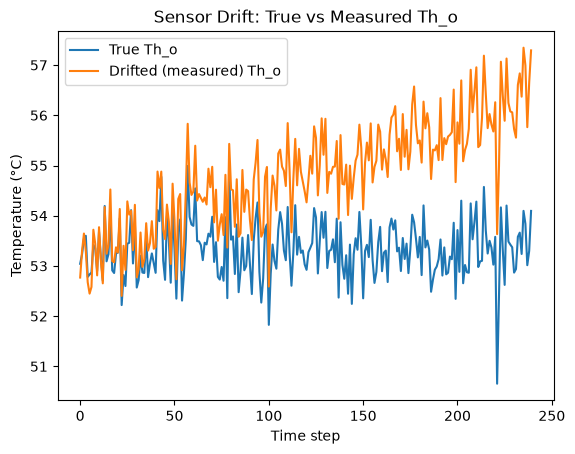

In [4]:
## SENSOR DRIFT - Th_o measurement drifts
#Load the CSV for our baseline data back in 
baseline_df = pd.read_csv("../data/baseline_data.csv")
Th_o_true = baseline_df["Th_o_true"].values
Tc_o_true = baseline_df["Tc_o_true"].values
sensor_noise_Th = np.random.normal(loc=0, scale=0.2, size=240)

#Creating the drift by 3 degrees
sensor_drift = np.linspace(0,3,240)
Th_o_drift = Th_o_true + sensor_noise_Th + sensor_drift

#Plotting the Th_true vs the Th_drift to visualise the drift and confirm it is happening
plt.plot(Th_o_true, label="True Th_o")
plt.plot(Th_o_drift, label="Drifted (measured) Th_o")
plt.xlabel("Time step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("Sensor Drift: True vs Measured Th_o")
plt.show()

#Add the sensor noise for the sensor drift fault to follow what would physically happen
sensor_noise_Th_sd = np.random.normal(loc=0, scale=0.2, size=240)
sensor_noise_Tc_sd = np.random.normal(loc=0, scale=0.2, size=240)

#Combine sensor drift and the noise for our measured values
Th_o_sd_measured = Th_o_true + sensor_noise_Th_sd + sensor_drift
Tc_o_sd_measured = Tc_o_true + sensor_noise_Tc_sd

#Create the sensor drift data frame with pandas
sensor_drift_dataframe = pd.DataFrame({
    "Timestamp": timestamps,
    "Th_i": Th_i_values,
    "Tc_i": Tc_i_values,
    "mdot_h": mdot_h_values,
    "mdot_c": mdot_c_values,
    "U": U,
    "Th_o_true": Th_o_true,
    "Tc_o_true": Tc_o_true,
    "Th_o_measured": Th_o_sd_measured,
    "Tc_o_measured": Tc_o_sd_measured
})

#Save to CSV
sensor_drift_dataframe.to_csv("../data/drift_fault_data.csv", index=False)


Flow Blockage:
A sudden step-change occurs randomly between 1 and 3 hours reducing the hot water flow rate by half, simulating 

In [5]:
## FLOW BLOCKAGE - Step change in mass flow rate of the hot water (I am creating it so there is a sudden drop off in flow rate)
mdot_h_blockage = mdot_h_values.copy() #We need to use a new array for our mdot values so the baseline values do not get permanently changed
blockage_start = np.random.randint(60,180) #Random integeger(time) for the blockage to occur
mdot_h_blockage[blockage_start:] = mdot_h_blockage[blockage_start:] * 0.5 #This will half the flow rate at the random time between 1 and 3 hours
print("Blockage starts at time step:", blockage_start) #Print statement so I can verify for later (detection)

#Check physically how the blockage affects Th_o
results_list_blockage = []
for i in range(240):
    result = effectiveness_ntu(Th_i_values[i], Tc_i_values[i], mdot_h_blockage[i], mdot_c_values[i], cp, U, A)
    results_list_blockage.append(result)

#Prints the results of the list 5 minutes before and after the blockage occurs
print(f"Blockage - 5 minutes before: {results_list_blockage[blockage_start-5]['Th_o']}")
print(f"Blockage - 5 minutes after: {results_list_blockage[blockage_start+5]['Th_o']}")

# Less mass flow in means that our same fluid will spend more time in the heat exhanger, so each unit of the fluid will have more heat taken out of it
# per kilogram, the temperature drop per unit of our hot water will be larger because there is less mass to absorb the heat.
# Physically mdot_h drops Ch as Ch = mdot_h x cp, and since Th_o = Th_i - Q/C_h and due to Ch dropping Th_o would get smaller proving this model.

#Extract Th_o and Tc_o from our results_list_blockage
Th_o_blockage = np.array([r["Th_o"] for r in results_list_blockage])
Tc_o_blockage = np.array([r["Tc_o"] for r in results_list_blockage])

#Re-create the sensor drift
sensor_noise_Th_blockage = np.random.normal(loc=0, scale=0.2, size=240)
sensor_noise_Tc_blockage = np.random.normal(loc=0, scale=0.2, size=240)

#Combine the blockage and noise values for measures values
Th_o_blockage_measured = Th_o_blockage + sensor_noise_Th_blockage
Tc_o_blockage_measured = Tc_o_blockage + sensor_noise_Tc_blockage

#Build the blockage data frame
blockage_dataframe = pd.DataFrame({
    "Timestamp": timestamps,
    "Th_i": Th_i_values,
    "Tc_i": Tc_i_values,
    "mdot_h": mdot_h_blockage,
    "mdot_c": mdot_c_values,
    "U": U,
    "Th_o_true": Th_o_blockage,
    "Tc_o_true": Tc_o_blockage,
    "Th_o_measured": Th_o_blockage_measured,
    "Tc_o_measured": Tc_o_blockage_measured
})

#Save blockage data to CSV
blockage_dataframe.to_csv("../data/blockage_fault_data.csv", index=False)

Blockage starts at time step: 77
Blockage - 5 minutes before: 53.51852546752953
Blockage - 5 minutes after: 40.421449373258795


Leak: A gradual leak at the hot water outlet affecting the mass balance of the heat exchanger. The leak bu

In [7]:
#Start with creating an array for the growing leak
leak_fraction = np.linspace(0, 0.07, 240) #Starts at no leak and grows to 7% leak over 4 hours

#Calculating the outlet flow rate 
mdot_h_outlet = mdot_h_values * (1 - leak_fraction) #Mass in multiplied by fraction that has not leaked

#Reusing the baseline Th_o and Tc_o values (The leak will not affect the heat exchange)
Th_o_leak = Th_o_true
Tc_o_leak = Tc_o_true

## Calculating the mismatch in the energy balance
C_h_inlet = mdot_h_values  * cp
C_h_outlet = mdot_h_outlet * cp

#Energy calculations
Q_base_inlet = C_h_inlet * (Th_i_values - Th_o_leak)
Q_outlet = C_h_outlet * (Th_i_values - Th_o_leak)

energy_mismatch = Q_base_inlet - Q_outlet #Calculating the mismatch

#Confirming that there is a mismatch 
print(f"Leak fraction early: {leak_fraction[0]:.4f}, late: {leak_fraction[-1]:.4f}")
print(f"Energy mismatch early: {energy_mismatch[0]:.2f} W, late: {energy_mismatch[-1]:.2f} W")

#Re-create the sensor drift
sensor_noise_Th_leak = np.random.normal(loc=0, scale=0.2, size=240)
sensor_noise_Tc_leak = np.random.normal(loc=0, scale=0.2, size=240)

#Combine the leaked and noise values for measures values
Th_o_leak_measured = Th_o_leak + sensor_noise_Th_leak
Tc_o_leak_measured = Tc_o_leak + sensor_noise_Tc_leak

#Creating noise at the sensor outlet (flow sensor)
sensor_noise_mdot_h = np.random.normal(loc=0, scale=0.01, size=240)   # small noise, flow sensors are typically precise
mdot_h_outlet_measured = mdot_h_outlet + sensor_noise_mdot_h

#Build the leakage data frame
leak_dataframe = pd.DataFrame({
    "Timestamp": timestamps,
    "Th_i": Th_i_values,
    "Tc_i": Tc_i_values,
    "mdot_h": mdot_h_values,
    "mdot_h_outlet": mdot_h_outlet_measured,
    "mdot_c": mdot_c_values,
    "U": U,
    "Th_o_true": Th_o_leak,
    "Tc_o_true": Tc_o_leak,
    "Th_o_measured": Th_o_leak_measured,
    "Tc_o_measured": Tc_o_leak_measured,
    "energy_mismatch": energy_mismatch
})

#Save to CSV 
leak_dataframe.to_csv("../data/leak_fault_data.csv", index=False)







Leak fraction early: 0.0000, late: 0.0700
Energy mismatch early: 0.00 W, late: 10738.51 W
